<a href="https://colab.research.google.com/github/Bindusri2294/Bindhu/blob/main/ML_PROJECRT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# SINGLE CODE: TRAIN + EPOCHS + METRICS + GRAPH
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# -------- 1. LOAD DATASET --------
df = pd.read_csv("/content/fruits_dataset.csv")

# -------- 2. SPLIT FEATURES & TARGET --------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# -------- 3. ENCODE FEATURE COLUMNS ONLY --------
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# -------- 4. ENCODE TARGET SEPARATELY (IMPORTANT FIX) --------
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)   # Now y = 0,1,2,...

# -------- 5. TRAIN-TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# -------- 6. FEATURE SCALING --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------- 7. ONE-HOT ENCODING TARGET --------
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# -------- 8. MODEL DEFINITION --------
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# -------- 9. COMPILE MODEL --------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------- 10. TRAIN MODEL --------
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16,
    verbose=1
)

# -------- 11. PREDICTION --------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# -------- 12. EVALUATION METRICS --------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# -------- 13. ACCURACY vs EPOCH GRAPH --------
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()





FileNotFoundError: [Errno 2] No such file or directory: '/content/fruits_dataset.csv'

In [ ]:
from google.colab import files
files.upload()    # upload fruits_dataset.csv


In [ ]:
# ============================================
# SINGLE CODE: TRAIN + EPOCHS + METRICS + GRAPH
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# -------- 1. LOAD DATASET --------
df = pd.read_csv("/content/fruits_dataset.csv")

# -------- 2. SPLIT FEATURES & TARGET --------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# -------- 3. ENCODE FEATURE COLUMNS ONLY --------
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# -------- 4. ENCODE TARGET SEPARATELY (IMPORTANT FIX) --------
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)   # Now y = 0,1,2,...

# -------- 5. TRAIN-TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# -------- 6. FEATURE SCALING --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------- 7. ONE-HOT ENCODING TARGET --------
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# -------- 8. MODEL DEFINITION --------
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# -------- 9. COMPILE MODEL --------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------- 10. TRAIN MODEL --------
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16,
    verbose=1
)

# -------- 11. PREDICTION --------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# -------- 12. EVALUATION METRICS --------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# -------- 13. ACCURACY vs EPOCH GRAPH --------
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()





In [9]:
# ============================================
# FULL CODE: LOAD + PREPROCESS + TRAIN + METRICS + GRAPH
# Dataset: zelda_food.csv
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# -------- 1. LOAD DATASET --------
df = pd.read_csv(r"zelda_food.csv")

print("Dataset Loaded Successfully")
print(df.head())

# -------- 2. HANDLE MISSING VALUES --------
df = df.dropna()   # simple & safe

# -------- 3. SPLIT FEATURES & TARGET --------
# ⚠️ Assumption: LAST column is TARGET
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# -------- 4. ENCODE FEATURE COLUMNS --------
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# -------- 5. ENCODE TARGET COLUMN --------
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# -------- 6. TRAIN-TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# -------- 7. FEATURE SCALING --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------- 8. ONE-HOT ENCODING TARGET --------
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# -------- 9. MODEL DEFINITION --------
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# -------- 10. COMPILE MODEL --------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------- 11. TRAIN MODEL --------
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16,
    verbose=1
)

# -------- 12. PREDICTION --------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# -------- 13. EVALUATION METRICS --------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# -------- 14. ACCURACY vs EPOCH GRAPH --------
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'zelda_food.csv'

KeyboardInterrupt: 

Files in /content:
['.config', 'archive (3).zip', 'zelda_food[1].csv', 'fruits_dataset.csv', 'sample_data']

Dataset Loaded Successfully
   Class Subclass           Material  Hearts Effect class when cooked  \
0  Fruit    Fruit              Apple     1.0                      NaN   
1  Fruit    Fruit  Fleet-Lotus Seeds     1.0                    Hasty   
2  Fruit    Fruit      Hearty Durian     6.0                   Hearty   
3  Fruit    Fruit         Hydromelon     1.0                   Chilly   
4  Fruit    Fruit     Mighty Bananas     1.0                   Mighty   

  Bonus effect when cooked Duration increase  
0                      NaN              0:30  
1                      NaN               NaN  
2                      max               NaN  
3                      NaN               NaN  
4                      NaN               NaN  
Dataset shape: (69, 7)
Shape after handling missing values: (69, 7)
X shape: (69, 6) y shape: (69,)
Epoch 1/30


/tmp/ipython-input-1321560305.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')   # forward fill
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.2258 - loss: 1.8964 - val_accuracy: 0.3571 - val_loss: 1.7672
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4776 - loss: 1.7807 - val_accuracy: 0.6429 - val_loss: 1.6394
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5337 - loss: 1.6592 - val_accuracy: 0.7857 - val_loss: 1.5180
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7763 - loss: 1.5240 - val_accuracy: 0.8571 - val_loss: 1.4035
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7544 - loss: 1.4287 - val_accuracy: 0.8571 - val_loss: 1.2938
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7544 - loss: 1.3160 - val_accuracy: 0.8571 - val_loss: 1.1920
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7273 - loss: 1.2774 - val_accuracy: 0.8571 - val_loss: 1.0969
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7898 - loss: 1.1165 - val_accuracy: 0.8571 - val_loss: 1.0066
Epoch 9/30


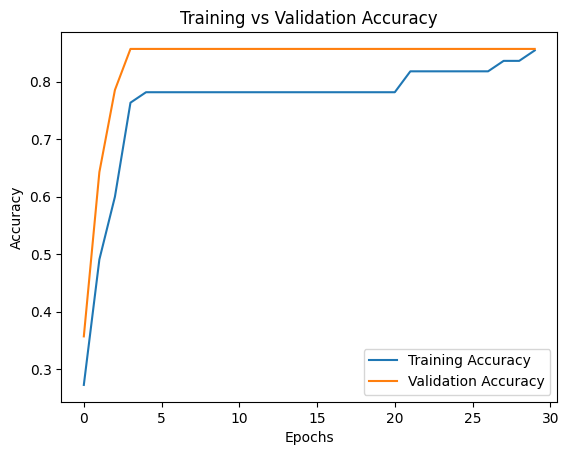

In [16]:
# ============================================
# FINAL SAFE CODE: zelda_food[1].csv
# Handles missing values, no n_samples=0 error
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# -------- 1. CHECK FILES --------
print("Files in /content:")
print(os.listdir("/content"))

# -------- 2. LOAD DATASET --------
df = pd.read_csv("/content/zelda_food[1].csv")
print("\nDataset Loaded Successfully")
print(df.head())
print("Dataset shape:", df.shape)

# -------- 3. HANDLE MISSING VALUES SAFELY --------
# Replace missing values with forward fill or 0
df = df.fillna(method='ffill')   # forward fill
# df = df.fillna(0)  # alternative: replace missing with 0

print("Shape after handling missing values:", df.shape)

# -------- 4. SPLIT FEATURES & TARGET --------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("X shape:", X.shape, "y shape:", y.shape)

# -------- 5. ENCODE FEATURE COLUMNS --------
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# -------- 6. ENCODE TARGET --------
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# -------- 7. TRAIN-TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# -------- 8. FEATURE SCALING --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------- 9. ONE-HOT ENCODING TARGET --------
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# -------- 10. MODEL --------
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# -------- 11. COMPILE MODEL --------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------- 12. TRAIN MODEL --------
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16,
    verbose=1
)

# -------- 13. PREDICT --------
y_pred = np.argmax(model.predict(X_test), axis=1)

# -------- 14. EVALUATION METRICS --------
print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")

# -------- 15. ACCURACY vs EPOCH GRAPH --------
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()
